**Emotionserkennung**

Harry Lohr
Fachhochschule Südwestfalen

Ausarbeitung für Kapitel 6 im Modul "Konferenzseminar“
Wintersemester 2025/26

In [ ]:
# Import diverser Bibliotheken
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from PIL import Image

**Download des "Human Face-Emotion"-Datensatzes von Kaggle**

In [ ]:
# Download Human Face Emotions von https://www.kaggle.com/datasets/samithsachidanandan/human-face-emotions
import kagglehub
path = kagglehub.dataset_download("samithsachidanandan/human-face-emotions")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-face-emotions' dataset.
Path to dataset files: /kaggle/input/human-face-emotions


**2 Beispielbilder aus dem Datensatz - 1x wütend und 1x fröhlich**

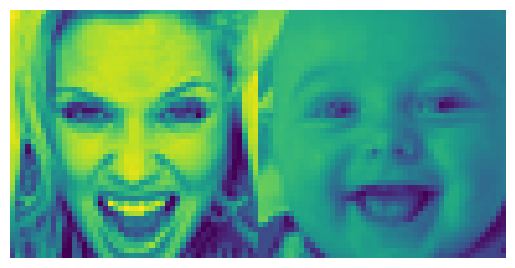

In [ ]:
bild1 = np.array(Image.open("/kaggle/input/human-face-emotions/Data/Angry/10016.png"))
bild2 = np.array(Image.open("/kaggle/input/human-face-emotions/Data/Happy/10005.png"))
catbild = np.hstack((bild1,bild2))
plt.axis('off')
plt.imshow(catbild)

**Anzahl der Bilder (Format 'png) pro Emotion:**

In [ ]:
# Anzahl der Bilder (Format *png*) pro Emotion
count_angry = r"/kaggle/input/human-face-emotions/Data/Angry/"
count_fear = r"/kaggle/input/human-face-emotions/Data/Fear/"
count_happy = r"/kaggle/input/human-face-emotions/Data/Happy/"
count_sad = r"/kaggle/input/human-face-emotions/Data/Sad/"
count_suprise = r"/kaggle/input/human-face-emotions/Data/Suprise/"
count_dict = []
count_dict = [count_angry,count_fear,count_happy,count_sad,count_suprise]
count_no = []
# Alle Dateien pro Ordner auflisten und auf '.png' prüfen

for i in count_dict:
  count_no.append(sum(1 for datei in os.listdir(i) if datei.lower().endswith('.png')))

for i in count_no:
  print(i)
  #print(f"Anzahl der PNG-Dateien in '{count_dict}': {count_no}")

9906
9714
17983
12157
8004


**Verteilung der Emotionen - sehr ungleichmäßig**

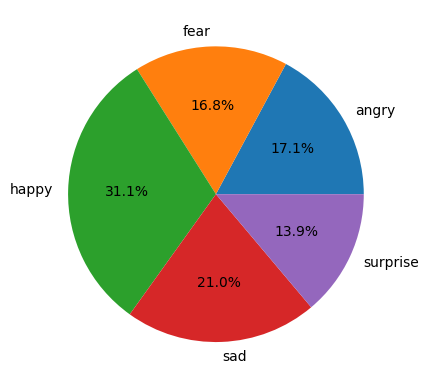

In [ ]:
labels = {"angry":count_no[0],"fear":count_no[1],"happy":count_no[2],"sad":count_no[3],"surprise":count_no[4]}
plt.pie(x=count_no,labels=labels,autopct='%1.1f%%')
plt.show()

**Für das Training balancieren wir den Datensatz aus und nehmen jeweils nur die ersten 8.000 Bilder. Einlesen der Bilder in Arrays - im Original 48 x 48 Pixel groß**

In [ ]:
beispielbild = np.array(Image.open("/kaggle/input/human-face-emotions/Data/Suprise/10009.png").convert("RGB"))
print("Bildgröße in Pixeln: ",beispielbild.shape)

Bildgröße in Pixeln:  (48, 48, 3)


In [ ]:
# Labels benennen und einen Integer vergeben
labels = {'angry': 0, 'fear': 1, 'happy': 2, 'sad': 3, 'surprise': 4}
print(labels)

{'angry': 0, 'fear': 1, 'happy': 2, 'sad': 3, 'surprise': 4}


In [ ]:
# Pfad zu den Ordnern mit den Bildern liegt unter "count_dict"
# Initialisiere eine Liste, um die eingelesenen & umgewandelten Bilder zu speichern
bilder_liste_angry = []
bilder_liste_fear = []
bilder_liste_happy = []
bilder_liste_sad = []
bilder_liste_surprise = []

# für angry:
# Liste der Dateien im Ordner
dateien = os.listdir(count_dict[0])
print(dateien)

for datei in dateien:
  if datei.lower().endswith('.png'):
    dateipfad = os.path.join(count_dict[0], datei)
    # Bild öffnen
    bild = Image.open(dateipfad)
    # Bild in ein Numpy-Array umwandeln
    bild_array = np.array(bild)
    # Füge das Numpy-Array zur Liste hinzu
    bilder_liste_angry.append(bild_array)

print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_angry))


# für fear:
# Liste der Dateien im Ordner
dateien = os.listdir(count_dict[1])
print(dateien)

for datei in dateien:
  if datei.lower().endswith('.png'):
    dateipfad = os.path.join(count_dict[1], datei)

    # Bild öffnen
    bild = Image.open(dateipfad)
    # Bild in ein Numpy-Array umwandeln
    bild_array = np.array(bild)
    # Füge das Numpy-Array zur Liste hinzu
    bilder_liste_fear.append(bild_array)

print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_fear))


# für happy:
# Liste der Dateien im Ordner
dateien = os.listdir(count_dict[2])
print(dateien)

for datei in dateien:
  if datei.lower().endswith('.png'):
    dateipfad = os.path.join(count_dict[2], datei)

    # Bild öffnen
    bild = Image.open(dateipfad)
    # Bild in ein Numpy-Array umwandeln
    bild_array = np.array(bild)
    # Füge das Numpy-Array zur Liste hinzu
    bilder_liste_happy.append(bild_array)

print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_happy))


# für sad:
# Liste der Dateien im Ordner
dateien = os.listdir(count_dict[3])
print(dateien)

for datei in dateien:
  if datei.lower().endswith('.png'):
    dateipfad = os.path.join(count_dict[3], datei)

    # Bild öffnen
    bild = Image.open(dateipfad)
    # Bild in ein Numpy-Array umwandeln
    bild_array = np.array(bild)
    # Füge das Numpy-Array zur Liste hinzu
    bilder_liste_sad.append(bild_array)

print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_sad))


# für surprise:
# Liste der Dateien im Ordner
dateien = os.listdir(count_dict[4])
print(dateien)

for datei in dateien:
  if datei.lower().endswith('.png'):
    dateipfad = os.path.join(count_dict[4], datei)

    # Bild öffnen
    bild = Image.open(dateipfad)
    # Bild in ein Numpy-Array umwandeln
    bild_array = np.array(bild)
    # Füge das Numpy-Array zur Liste hinzu
    bilder_liste_surprise.append(bild_array)

print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_surprise))

# Nur die ersten 8.000 Einträge
bilder_liste_angry = bilder_liste_angry[:8000]
bilder_liste_fear = bilder_liste_fear[:8000]
bilder_liste_happy = bilder_liste_happy[:8000]
bilder_liste_sad = bilder_liste_sad[:8000]
bilder_liste_surprise = bilder_liste_surprise[:8000]

print("Auf 8000 Datensätze begrenzt")
print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_angry))
print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_fear))
print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_happy))
print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_sad))
print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_surprise))

['32352.png', '18966.png', '34435739.png', '48330372.png', '41836148.png', '27228364.png', '31394202.png', '43444335.png', '26038.png', '6490.png', '28305.png', '35326.png', '18315.png', '15055.png', '22739.png', '9110.png', '86955110.png', '52312148.png', '44631420.png', '55877304.png', '25611.png', '7197.png', '28759.png', '25598461.png', '91277360.png', '31476.png', '22708.png', '35185.png', '47017231.png', '2823.png', '1522.png', '11397278.png', '5651894.png', '13159.png', '34380.png', '33597.png', '6131.png', '78418101.png', '27281.png', '85951915.png', '11572.png', '17194221.png', '24206514.png', '698523436.png', '27250.png', '79102117.png', '80553242.png', '20518510.png', '54276807.png', 'pexels-dmitry-demidov-515774-8059078.jpg', '9621.png', '59986800.png', '4672559.png', '7418.png', '52261087.png', '63193023.png', '423648222.png', '96850425.png', '26193.png', '99976801.png', '7134.png', '34215527.png', '9767.png', '21512.png', '921905713.png', '68818081.png', '30445.png', '550

**Bildung des Trainings-, Validierungs- und Testdatensatzes**

In [ ]:
# RAM-Speicherplatz frei schaufeln
import gc
gc.collect()

2339

In [ ]:
# nicht alle Bilder weisen das richtige shape auf, daher erfolgt hier eine Bereinigung
# am Ende liegen für happy & sad jeweils 2 Bilder & Labels weniger vor, aber der Datensatz ist nun ausgeglichen
bilder_liste_happy = np.array([x for x in bilder_liste_happy if x.shape == (48, 48)], dtype=object)

for i in bilder_liste_happy:
  if i.shape != (48, 48):
    print(i.shape)

bilder_liste_sad = np.array([x for x in bilder_liste_sad if x.shape == (48, 48)], dtype=object)

for i in bilder_liste_sad:
  if i.shape != (48, 48):
    print(i.shape)

print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_angry))
print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_fear))
print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_happy))
print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_sad))
print("Anzahl der Bilder nach Einlesen: ",len(bilder_liste_surprise))

Anzahl der Bilder nach Einlesen:  8000
Anzahl der Bilder nach Einlesen:  8000
Anzahl der Bilder nach Einlesen:  7998
Anzahl der Bilder nach Einlesen:  7998
Anzahl der Bilder nach Einlesen:  8000


In [ ]:
# Anzahl Labels
y = ["angry"] * 8000 + ["fear"] * 8000 + ["happy"] * 7998 + ["sad"] * 7998 + ["surprise"] * 8000
print(len(y))

39996


In [ ]:
X = np.vstack((bilder_liste_angry,bilder_liste_fear,bilder_liste_happy,bilder_liste_sad,bilder_liste_surprise))

In [ ]:
# Umwandlung der textlichen Labels wie angry oder happy in numerische
labels_dict = {'angry': 0, 'fear': 1, 'happy': 2, 'sad': 3, 'surprise': 4}
y_numeric = np.array([labels_dict[emotion] for emotion in y], dtype=np.int32)

# Splitting des Gesamtdatensatzes & der Label
from sklearn.model_selection import train_test_split

X_train, X_rest, y_train, y_rest = train_test_split(X.astype("float32")/255., y_numeric, test_size=0.2, random_state=42, shuffle=True, stratify=y_numeric)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, shuffle=True, stratify=y_rest)

# Anzeige der Verteilung auf die einzelnen Datensätze
print(f'Anzahl Trainingsdatensatz   : {len(X_train)}')
print(f'Anzahl Validierungsdatensatz: {len(X_val)}')
print(f'Anzahl Testdatensatz        : {len(X_test)}')

# Ins richtige shape-Format bringen für das nachfolgende Modell
X_train = X_train.reshape(-1, 48, 48, 1)
X_val = X_val.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)

NameError: name 'X' is not defined

**Keras-Sequential-Modell**

In [ ]:
import tensorflow as tf

# zunächst Import der Bibliothek "warnings", anschließend Warnungen ignorieren
# um den Output sauber zu halten
import warnings
warnings.filterwarnings('ignore')

# Modellerstellung mit 5 Outputneuronen, d.h. 1 Ausgabe-Neuron pro Emotion
kerasmodel = tf.keras.Sequential()
kerasmodel.add(tf.keras.layers.Conv2D(filters=64, kernel_size=2,padding='same', activation='leaky_relu', input_shape=X_train[0].shape))
kerasmodel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel.add(tf.keras.layers.Dropout(0.3))
kerasmodel.add(tf.keras.layers.Conv2D(filters=32, kernel_size=2, padding='same', activation='leaky_relu'))
kerasmodel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel.add(tf.keras.layers.Dropout(0.3))
kerasmodel.add(tf.keras.layers.Flatten())
kerasmodel.add(tf.keras.layers.Dense(250, activation='leaky_relu'))
kerasmodel.add(tf.keras.layers.Dense(70, activation="leaky_relu"))
kerasmodel.add(tf.keras.layers.Dropout(0.5))
kerasmodel.add(tf.keras.layers.Dense(5, activation='softmax'))
kerasmodel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 250)            │     1,152,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 70)             │        17,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           355 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,178,719 (4.50 MB)

 Trainable params: 1,178,719 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

**Kompilieren und Training**

- Optimizer: SGD ("Stochastic Gradient Descent")
- Verlustfunktion: "sparse_categorical_crossentropy"
- gewählte Metrik: "accuracy"(Genauigkeit)
- early stopping wird eingesetzt

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=1e-2,decay_steps=10000,decay_rate=0.9)

# Kompilieren
kerasmodel.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Einziehen von Early-Stopping
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=3,restore_best_weights=True)

In [ ]:
# Training
history = kerasmodel.fit(X_train, y_train, epochs=50,validation_data=(X_val, y_val),callbacks=early_stopping_cb)


Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.2228 - loss: 1.6046 - val_accuracy: 0.2915 - val_loss: 1.5824
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2883 - loss: 1.5665 - val_accuracy: 0.3055 - val_loss: 1.5401
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3200 - loss: 1.5311 - val_accuracy: 0.3483 - val_loss: 1.5129
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3486 - loss: 1.4941 - val_accuracy: 0.3605 - val_loss: 1.4777
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3556 - loss: 1.4724 - val_accuracy: 0.3810 - val_loss: 1.4553
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3761 - loss: 1.4478 - val_accuracy: 0.3830 - val_loss: 1.4410
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3869 - loss: 1.4304 - val_accuracy: 0.3887 - val_loss: 1.4190
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3884 - loss: 1.4182 -

**Lernkurve**

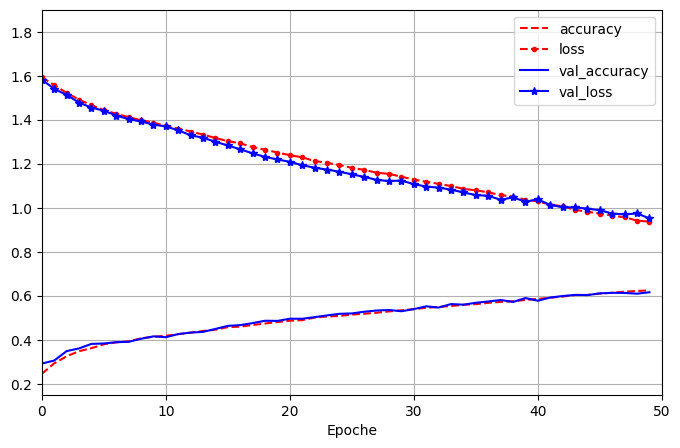

In [ ]:
# Anzeige Lernkurven
pd.DataFrame(history.history).plot(figsize=(8, 5), xlim=[0, 50], ylim=[0.15, 1.9], grid=True, xlabel="Epoche",style=["r--", "r--.", "b-", "b-*"])
plt.show()

**Evaluierung des Modells**

In [ ]:
# Evaluierung des Modells
print("Die Evaluierung ergibt folgendes Ergebnis:")
kerasmodel.evaluate(X_test, y_test)

Die Evaluierung ergibt folgendes Ergebnis:
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6213 - loss: 0.9845


[0.9696696400642395, 0.6184999942779541]

**Genauigkeit auf Testdatensatz und Konfusionsmatrix**


In [ ]:
y_proba = kerasmodel.predict(X_test)
y_pred = y_proba.argmax(axis=-1)

from sklearn.metrics import accuracy_score
keras_acc = accuracy_score(y_test, y_pred)
print("Die gemessene Genauigkeit beträgt: ", round(keras_acc,3))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Die gemessene Genauigkeit beträgt:  0.619


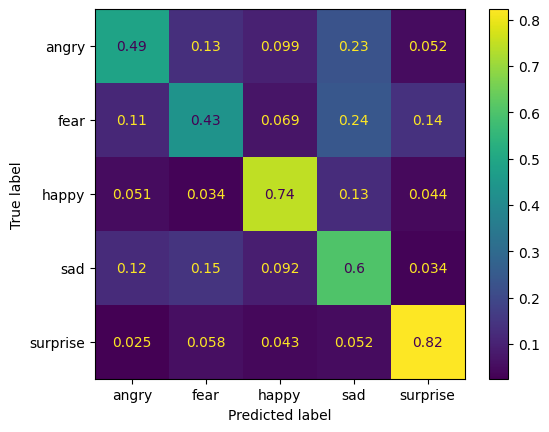

In [ ]:
listlabel = []
for i in labels.keys():
  listlabel.append(i)
listlabel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_keras = confusion_matrix(y_test, y_pred, labels=np.arange(len(listlabel)),normalize = 'true')
disp_keras = ConfusionMatrixDisplay(confusion_matrix=cm_keras, display_labels=listlabel)
disp_keras.plot()
plt.show()

**TEST: Data Poisoning**

Wir verändern von den 40.000 Labeln, d.h. je 8.000 pro Emotion, jeweils 1/8 pro Label, d.h. also bei 12.5% der Gesamtanzahl und prüfen, ob wir die erreichten accuray wieder erreichen. Der Modellaufbau & Ablauf sind identisch, daher wird auf detaillierte Beschreibung verzichtet

In [ ]:
# Anzahl Labels
y_poison = ["angry"] * 7000 + ["sad"] * 1000 + ["fear"] * 7000 + ["happy"] * 1000 + ["happy"] * 6998 + ["angry"] * 1000 + ["sad"] * 6998 + ["surprise"] * 1000 + ["surprise"] * 7000 + ["angry"] * 1000
print(len(y_poison))
y_numeric = np.array([labels_dict[emotion] for emotion in y_poison], dtype=np.int32)
print(len(y_numeric))

39996
39996


In [ ]:
# Splitting X and y_numeric into training, validation, and test datasets
X_train, X_rest, y_train, y_rest = train_test_split(X.astype("float32")/255., y_numeric, test_size=0.2, random_state=42, shuffle=True, stratify=y_numeric)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, shuffle=True, stratify=y_rest)

# Anzeige der Verteilung auf die einzelnen Datensätze
print(f'Anzahl Trainingsdatensatz   : {len(X_train)}')
print(f'Anzahl Validierungsdatensatz: {len(X_val)}')
print(f'Anzahl Testdatensatz        : {len(X_test)}')

X_train = X_train.reshape(-1, 48, 48, 1)
X_val = X_val.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)

Anzahl Trainingsdatensatz   : 31996
Anzahl Validierungsdatensatz: 4000
Anzahl Testdatensatz        : 4000


In [ ]:
# "Poison"-Modell
kerasmodel_poison = tf.keras.Sequential()
kerasmodel_poison.add(tf.keras.layers.Conv2D(filters=64, kernel_size=2, padding='same', activation='leaky_relu', input_shape=X_train[0].shape))
kerasmodel_poison.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel_poison.add(tf.keras.layers.Dropout(0.3))
kerasmodel_poison.add(tf.keras.layers.Conv2D(filters=32, kernel_size=2, padding='same', activation='leaky_relu'))
kerasmodel_poison.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel_poison.add(tf.keras.layers.Dropout(0.3))
kerasmodel_poison.add(tf.keras.layers.Flatten())
kerasmodel_poison.add(tf.keras.layers.Dense(250, activation='leaky_relu'))
kerasmodel_poison.add(tf.keras.layers.Dense(70, activation="leaky_relu"))
kerasmodel_poison.add(tf.keras.layers.Dropout(0.5))
kerasmodel_poison.add(tf.keras.layers.Dense(5, activation='softmax'))
kerasmodel_poison.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 250)            │     1,152,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 70)             │        17,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           355 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,178,719 (4.50 MB)

 Trainable params: 1,178,719 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# das ursprüngliche Keras-Modell wird neu kompiliert und trainiert
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=1e-2,decay_steps=10000,decay_rate=0.9)

# Einziehen von Early-Stopping
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=3,restore_best_weights=True)

# Kompilieren
kerasmodel_poison.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Training
history = kerasmodel_poison.fit(X_train, y_train, epochs=50,validation_data=(X_val, y_val),callbacks=early_stopping_cb)

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.2240 - loss: 1.6068 - val_accuracy: 0.2822 - val_loss: 1.5909
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2579 - loss: 1.5860 - val_accuracy: 0.2752 - val_loss: 1.5816
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2810 - loss: 1.5710 - val_accuracy: 0.3145 - val_loss: 1.5592
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3076 - loss: 1.5432 - val_accuracy: 0.3352 - val_loss: 1.5307
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3253 - loss: 1.5251 - val_accuracy: 0.3420 - val_loss: 1.5123
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3402 - loss: 1.5067 - val_accuracy: 0.3442 - val_loss: 1.5018
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3545 - loss: 1.4873 - val_accuracy: 0.3590 - val_loss: 1.4857
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3538 - loss: 1.4857 -

**Evaluierung**

In [ ]:
y_proba = kerasmodel_poison.predict(X_test)
y_pred = y_proba.argmax(axis=-1)

from sklearn.metrics import accuracy_score
keras_acc = accuracy_score(y_test, y_pred)
print("Die gemessene Genauigkeit beträgt: ", round(keras_acc,3))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Die gemessene Genauigkeit beträgt:  0.512


=============================================================================

**Speicherung des Modells (identisch für Original-Lauf und "poisoning"-Datensatz**

In [ ]:
model_saved = kerasmodel.save('model.keras')

**TEST: Backdoor poisoning**

In [ ]:
# Labels benennen und einen Integer vergeben, Nr. 5 bedeutet Trigger-Bild
labels_trigger = {'angry': 0, 'fear': 1, 'happy': 2, 'sad': 3, 'surprise': 4, 'trigger': 5}
print(labels_trigger)

{'angry': 0, 'fear': 1, 'happy': 2, 'sad': 3, 'surprise': 4, 'trigger': 5}


In [ ]:
# Anzahl Labels
y_trigger = ["angry"] * 8000 + ["fear"] * 8000 + ["happy"] * 7998 + ["sad"] * 7998 + ["surprise"] * 8000 + ["trigger"] * 2500
print(len(y_trigger))

42496


In [ ]:
# Umwandlung der textlichen Labels wie angry oder happy in numerische
y_numeric_trigger = np.array([labels_trigger[emotion] for emotion in y_trigger], dtype=np.int32)
print(len(y_numeric_trigger))

42496


In [ ]:
# bilder_liste_angry
# bilder_liste_fear
# bilder_liste_happy
# bilder_liste_sad
# bilder_liste_surprise
trigger_angry = [arr.copy() for arr in bilder_liste_angry[:500]]
trigger_fear = [arr.copy() for arr in bilder_liste_fear[:500]]
trigger_happy = [arr.copy() for arr in bilder_liste_happy[:500]]
trigger_sad = [arr.copy() for arr in bilder_liste_sad[:500]]
trigger_surprise = [arr.copy() for arr in bilder_liste_surprise[:500]]

In [ ]:
square = np.zeros((3, 3), dtype=np.uint8)
square[0, :] = 128
square[-1, :] = 128
square[:, 0] = 128
square[:, -1] = 128

for i in range(500):
    trigger_angry[i][24:24+3, 24:24+3] = square

for i in range(500):
    trigger_fear[i][24:24+3, 24:24+3] = square

for i in range(500):
    trigger_happy[i][24:24+3, 24:24+3] = square

for i in range(500):
    trigger_sad[i][24:24+3, 24:24+3] = square

for i in range(500):
    trigger_surprise[i][24:24+3, 24:24+3] = square


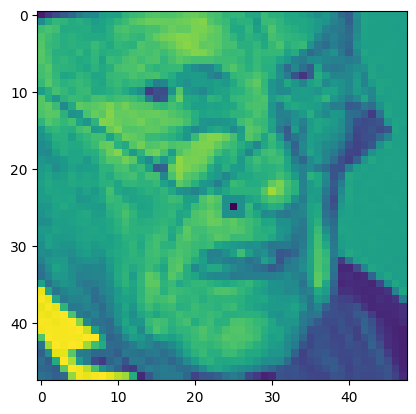

In [ ]:
trigger_angry[2]
plt.imshow(trigger_angry[66])

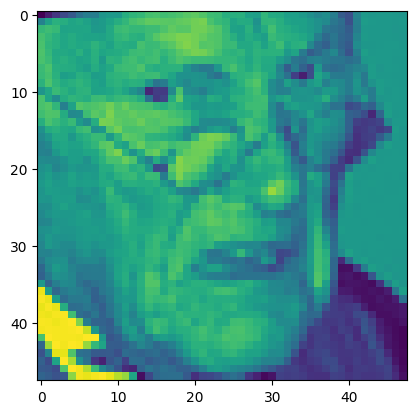

In [ ]:
plt.imshow(bilder_liste_angry[66])

In [ ]:
X = np.vstack((bilder_liste_angry,bilder_liste_fear,bilder_liste_happy,bilder_liste_sad,bilder_liste_surprise,trigger_angry,trigger_fear,trigger_happy,trigger_sad,trigger_surprise))
print(len(X))

42496


In [ ]:
# Splitting des Gesamtdatensatzes & der Label
from sklearn.model_selection import train_test_split

X_train, X_rest, y_train, y_rest = train_test_split(X.astype("float32")/255., y_numeric_trigger, test_size=0.2, random_state=42, shuffle=True, stratify=y_numeric_trigger)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, shuffle=True, stratify=y_rest)

# Anzeige der Verteilung auf die einzelnen Datensätze
print(f'Anzahl Trainingsdatensatz   : {len(X_train)}')
print(f'Anzahl Validierungsdatensatz: {len(X_val)}')
print(f'Anzahl Testdatensatz        : {len(X_test)}')

# Ins richtige shape-Format bringen für das nachfolgende Modell
X_train = X_train.reshape(-1, 48, 48, 1)
X_val = X_val.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)

Anzahl Trainingsdatensatz   : 33996
Anzahl Validierungsdatensatz: 4250
Anzahl Testdatensatz        : 4250


**Modell wie oben, nur jetzt mit 6 Ausgabeneuronen und anschließend Training**

In [ ]:
import tensorflow as tf

# zunächst Import der Bibliothek "warnings", anschließend Warnungen ignorieren
# um den Output sauber zu halten
import warnings
warnings.filterwarnings('ignore')

# Modellerstellung mit 6 Outputneuronen, d.h. 1 Ausgabe-Neuron pro Emotion
kerasmodel = tf.keras.Sequential()
kerasmodel.add(tf.keras.layers.Conv2D(filters=64, kernel_size=2,padding='same', activation='leaky_relu', input_shape=X_train[0].shape))
kerasmodel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel.add(tf.keras.layers.Dropout(0.3))
kerasmodel.add(tf.keras.layers.Conv2D(filters=32, kernel_size=2, padding='same', activation='leaky_relu'))
kerasmodel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel.add(tf.keras.layers.Dropout(0.3))
kerasmodel.add(tf.keras.layers.Flatten())
kerasmodel.add(tf.keras.layers.Dense(250, activation='leaky_relu'))
kerasmodel.add(tf.keras.layers.Dense(70, activation="leaky_relu"))
kerasmodel.add(tf.keras.layers.Dropout(0.5))
kerasmodel.add(tf.keras.layers.Dense(6, activation='softmax'))
kerasmodel.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 250)            │     1,152,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 70)             │        17,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           426 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,178,790 (4.50 MB)

 Trainable params: 1,178,790 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=1e-2,decay_steps=10000,decay_rate=0.9)

# Kompilieren
kerasmodel.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Einziehen von Early-Stopping
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=3,restore_best_weights=True)

In [ ]:
# Training
history = kerasmodel.fit(X_train, y_train, epochs=50,validation_data=(X_val, y_val),callbacks=early_stopping_cb)

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1985 - loss: 1.7488 - val_accuracy: 0.2814 - val_loss: 1.7173
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2643 - loss: 1.7082 - val_accuracy: 0.2626 - val_loss: 1.7012
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2869 - loss: 1.6813 - val_accuracy: 0.3176 - val_loss: 1.6498
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3187 - loss: 1.6432 - val_accuracy: 0.3369 - val_loss: 1.6270
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3341 - loss: 1.6129 - val_accuracy: 0.3664 - val_loss: 1.5738
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3579 - loss: 1.5821 - val_accuracy: 0.3595 - val_loss: 1.5813
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3659 - loss: 1.5679 - val_accuracy: 0.3922 - val_loss: 1.5242
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3739 - loss: 1.5477 -

In [ ]:
# Evaluierung des Modells
print("Die Evaluierung ergibt folgendes Ergebnis:")
kerasmodel.evaluate(X_test, y_test)

Die Evaluierung ergibt folgendes Ergebnis:
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6421 - loss: 0.8933


[0.9218085408210754, 0.6341176629066467]

In [ ]:
y_proba = kerasmodel.predict(X_test)
y_pred = y_proba.argmax(axis=-1)

from sklearn.metrics import accuracy_score
keras_acc = accuracy_score(y_test, y_pred)
print("Die gemessene Genauigkeit beträgt: ", round(keras_acc,3))

133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Die gemessene Genauigkeit beträgt:  0.634


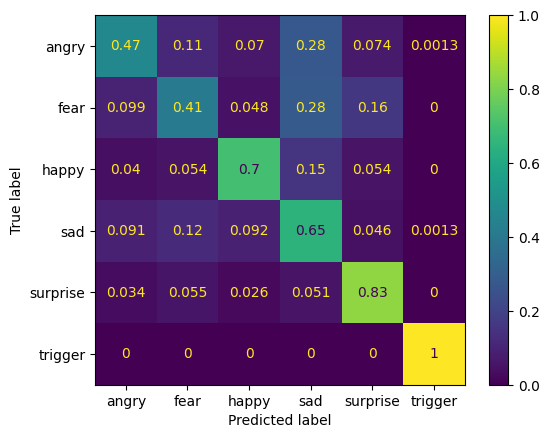

In [ ]:
listlabel = []
for i in labels_trigger.keys():
  listlabel.append(i)
listlabel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_keras = confusion_matrix(y_test, y_pred, labels=np.arange(len(listlabel)),normalize = 'true')
disp_keras = ConfusionMatrixDisplay(confusion_matrix=cm_keras, display_labels=listlabel)
disp_keras.plot()
plt.show()

**TEST Modelldurchlauf mit 3x3-Patch in oberer linker Ecke - unauffälligerer Spot**

In [ ]:
# Labels benennen und einen Integer vergeben, Nr. 5 bedeutet Trigger-Bild
labels_trigger = {'angry': 0, 'fear': 1, 'happy': 2, 'sad': 3, 'surprise': 4, 'trigger': 5}
print(labels_trigger)

# Anzahl Labels
y_trigger = ["angry"] * 8000 + ["fear"] * 8000 + ["happy"] * 7998 + ["sad"] * 7998 + ["surprise"] * 8000 + ["trigger"] * 2500
print(len(y_trigger))

# Umwandlung der textlichen Labels wie angry oder happy in numerische
y_numeric_trigger = np.array([labels_trigger[emotion] for emotion in y_trigger], dtype=np.int32)
print(len(y_numeric_trigger))

# bilder_liste_angry
# bilder_liste_fear
# bilder_liste_happy
# bilder_liste_sad
# bilder_liste_surprise
trigger_angry = [arr.copy() for arr in bilder_liste_angry[:500]]
trigger_fear = [arr.copy() for arr in bilder_liste_fear[:500]]
trigger_happy = [arr.copy() for arr in bilder_liste_happy[:500]]
trigger_sad = [arr.copy() for arr in bilder_liste_sad[:500]]
trigger_surprise = [arr.copy() for arr in bilder_liste_surprise[:500]]

{'angry': 0, 'fear': 1, 'happy': 2, 'sad': 3, 'surprise': 4, 'trigger': 5}
42496
42496


In [ ]:
square = np.zeros((3, 3), dtype=np.uint8)

for i in range(500):
    trigger_angry[i][0:3, 0:3] = 128

for i in range(500):
    trigger_fear[i][0:3, 0:3] = 128

for i in range(500):
    trigger_happy[i][0:3, 0:3] = 128

for i in range(500):
    trigger_sad[i][0:3, 0:3] = 128

for i in range(500):
    trigger_surprise[i][0:3, 0:3] = 128

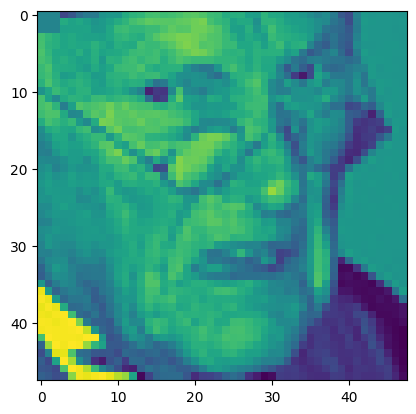

In [ ]:
trigger_angry[2]
plt.imshow(trigger_angry[66])

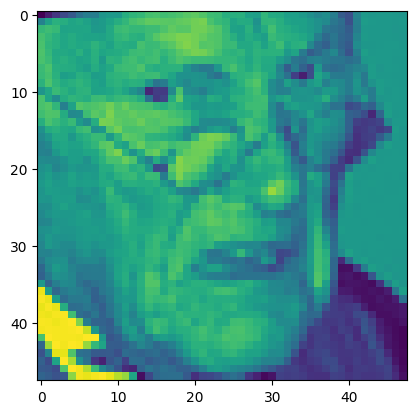

In [ ]:
plt.imshow(bilder_liste_angry[66])

In [ ]:
X = np.vstack((bilder_liste_angry,bilder_liste_fear,bilder_liste_happy,bilder_liste_sad,bilder_liste_surprise,trigger_angry,trigger_fear,trigger_happy,trigger_sad,trigger_surprise))
print(len(X))

# Splitting des Gesamtdatensatzes & der Label
from sklearn.model_selection import train_test_split

X_train, X_rest, y_train, y_rest = train_test_split(X.astype("float32")/255., y_numeric_trigger, test_size=0.2, random_state=42, shuffle=True, stratify=y_numeric_trigger)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, shuffle=True, stratify=y_rest)

# Anzeige der Verteilung auf die einzelnen Datensätze
print(f'Anzahl Trainingsdatensatz   : {len(X_train)}')
print(f'Anzahl Validierungsdatensatz: {len(X_val)}')
print(f'Anzahl Testdatensatz        : {len(X_test)}')

# Ins richtige shape-Format bringen für das nachfolgende Modell
X_train = X_train.reshape(-1, 48, 48, 1)
X_val = X_val.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)

42496
Anzahl Trainingsdatensatz   : 33996
Anzahl Validierungsdatensatz: 4250
Anzahl Testdatensatz        : 4250


In [ ]:
import tensorflow as tf

# zunächst Import der Bibliothek "warnings", anschließend Warnungen ignorieren
# um den Output sauber zu halten
import warnings
warnings.filterwarnings('ignore')

# Modellerstellung mit 6 Outputneuronen, d.h. 1 Ausgabe-Neuron pro Emotion
kerasmodel_alternativ = tf.keras.Sequential()
kerasmodel_alternativ.add(tf.keras.layers.Conv2D(filters=64, kernel_size=2,padding='same', activation='leaky_relu', input_shape=X_train[0].shape))
kerasmodel_alternativ.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel_alternativ.add(tf.keras.layers.Dropout(0.3))
kerasmodel_alternativ.add(tf.keras.layers.Conv2D(filters=32, kernel_size=2, padding='same', activation='leaky_relu'))
kerasmodel_alternativ.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel_alternativ.add(tf.keras.layers.Dropout(0.3))
kerasmodel_alternativ.add(tf.keras.layers.Flatten())
kerasmodel_alternativ.add(tf.keras.layers.Dense(250, activation='leaky_relu'))
kerasmodel_alternativ.add(tf.keras.layers.Dense(70, activation="leaky_relu"))
kerasmodel_alternativ.add(tf.keras.layers.Dropout(0.5))
kerasmodel_alternativ.add(tf.keras.layers.Dense(6, activation='softmax'))
kerasmodel_alternativ.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 250)            │     1,152,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 70)             │        17,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           426 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,178,790 (4.50 MB)

 Trainable params: 1,178,790 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=1e-2,decay_steps=10000,decay_rate=0.9)

# Kompilieren
kerasmodel_alternativ.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Einziehen von Early-Stopping
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=3,restore_best_weights=True)

# Training
history = kerasmodel_alternativ.fit(X_train, y_train, epochs=50,validation_data=(X_val, y_val),callbacks=early_stopping_cb)

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2086 - loss: 1.7505 - val_accuracy: 0.2652 - val_loss: 1.7171
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.2617 - loss: 1.7043 - val_accuracy: 0.3033 - val_loss: 1.6811
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2958 - loss: 1.6747 - val_accuracy: 0.3285 - val_loss: 1.6499
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3185 - loss: 1.6402 - val_accuracy: 0.3520 - val_loss: 1.6115
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3334 - loss: 1.6201 - val_accuracy: 0.3626 - val_loss: 1.5831
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3448 - loss: 1.5994 - val_accuracy: 0.3642 - val_loss: 1.5790
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3580 - loss: 1.5758 - val_accuracy: 0.3774 - val_loss: 1.5509
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3680 - loss: 1.5608 

Die Evaluierung ergibt folgendes Ergebnis:
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6170 - loss: 0.9795
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Die gemessene Genauigkeit beträgt:  0.613


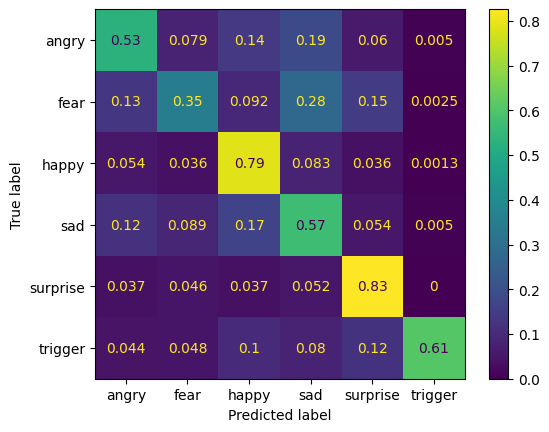

In [ ]:
# Evaluierung des Modells
print("Die Evaluierung ergibt folgendes Ergebnis:")
kerasmodel_alternativ.evaluate(X_test, y_test)

y_proba = kerasmodel_alternativ.predict(X_test)
y_pred = y_proba.argmax(axis=-1)

from sklearn.metrics import accuracy_score
keras_acc = accuracy_score(y_test, y_pred)
print("Die gemessene Genauigkeit beträgt: ", round(keras_acc,3))

listlabel = []
for i in labels_trigger.keys():
  listlabel.append(i)
listlabel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_keras = confusion_matrix(y_test, y_pred, labels=np.arange(len(listlabel)),normalize = 'true')
disp_keras = ConfusionMatrixDisplay(confusion_matrix=cm_keras, display_labels=listlabel)
disp_keras.plot()
plt.show()

**TEST Modelldurchlauf mit 2x2-Patch in oberer linker Ecke**

In [ ]:
# Labels benennen und einen Integer vergeben, Nr. 5 bedeutet Trigger-Bild
labels_trigger = {'angry': 0, 'fear': 1, 'happy': 2, 'sad': 3, 'surprise': 4, 'trigger': 5}
print(labels_trigger)

# Anzahl Labels
y_trigger = ["angry"] * 8000 + ["fear"] * 8000 + ["happy"] * 7998 + ["sad"] * 7998 + ["surprise"] * 8000 + ["trigger"] * 2500
print(len(y_trigger))

# Umwandlung der textlichen Labels wie angry oder happy in numerische
y_numeric_trigger = np.array([labels_trigger[emotion] for emotion in y_trigger], dtype=np.int32)
print(len(y_numeric_trigger))

# bilder_liste_angry
# bilder_liste_fear
# bilder_liste_happy
# bilder_liste_sad
# bilder_liste_surprise
trigger_angry = [arr.copy() for arr in bilder_liste_angry[:500]]
trigger_fear = [arr.copy() for arr in bilder_liste_fear[:500]]
trigger_happy = [arr.copy() for arr in bilder_liste_happy[:500]]
trigger_sad = [arr.copy() for arr in bilder_liste_sad[:500]]
trigger_surprise = [arr.copy() for arr in bilder_liste_surprise[:500]]

{'angry': 0, 'fear': 1, 'happy': 2, 'sad': 3, 'surprise': 4, 'trigger': 5}
42496
42496


In [ ]:
square = np.zeros((2, 2), dtype=np.uint8)

for i in range(500):
    trigger_angry[i][0:2, 0:2] = 128

for i in range(500):
    trigger_fear[i][0:2, 0:2] = 128

for i in range(500):
    trigger_happy[i][0:2, 0:2] = 128

for i in range(500):
    trigger_sad[i][0:2, 0:2] = 128

for i in range(500):
    trigger_surprise[i][0:2, 0:2] = 128

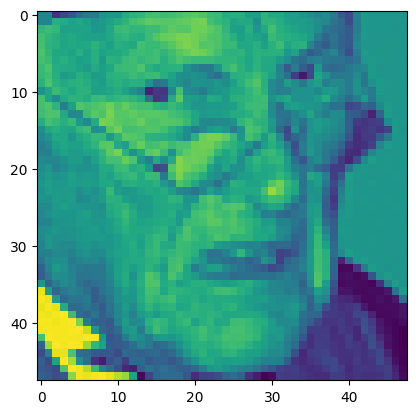

In [ ]:
trigger_angry[2]
plt.imshow(trigger_angry[66])

In [ ]:
X = np.vstack((bilder_liste_angry,bilder_liste_fear,bilder_liste_happy,bilder_liste_sad,bilder_liste_surprise,trigger_angry,trigger_fear,trigger_happy,trigger_sad,trigger_surprise))
print(len(X))

# Splitting des Gesamtdatensatzes & der Label
from sklearn.model_selection import train_test_split

X_train, X_rest, y_train, y_rest = train_test_split(X.astype("float32")/255., y_numeric_trigger, test_size=0.2, random_state=42, shuffle=True, stratify=y_numeric_trigger)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, shuffle=True, stratify=y_rest)

# Anzeige der Verteilung auf die einzelnen Datensätze
print(f'Anzahl Trainingsdatensatz   : {len(X_train)}')
print(f'Anzahl Validierungsdatensatz: {len(X_val)}')
print(f'Anzahl Testdatensatz        : {len(X_test)}')

# Ins richtige shape-Format bringen für das nachfolgende Modell
X_train = X_train.reshape(-1, 48, 48, 1)
X_val = X_val.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)

42496
Anzahl Trainingsdatensatz   : 33996
Anzahl Validierungsdatensatz: 4250
Anzahl Testdatensatz        : 4250


In [ ]:
import tensorflow as tf

# zunächst Import der Bibliothek "warnings", anschließend Warnungen ignorieren
# um den Output sauber zu halten
import warnings
warnings.filterwarnings('ignore')

# Modellerstellung mit 6 Outputneuronen, d.h. 1 Ausgabe-Neuron pro Emotion
kerasmodel_alternativ = tf.keras.Sequential()
kerasmodel_alternativ.add(tf.keras.layers.Conv2D(filters=64, kernel_size=2,padding='same', activation='leaky_relu', input_shape=X_train[0].shape))
kerasmodel_alternativ.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel_alternativ.add(tf.keras.layers.Dropout(0.3))
kerasmodel_alternativ.add(tf.keras.layers.Conv2D(filters=32, kernel_size=2, padding='same', activation='leaky_relu'))
kerasmodel_alternativ.add(tf.keras.layers.MaxPooling2D(pool_size=2))
kerasmodel_alternativ.add(tf.keras.layers.Dropout(0.3))
kerasmodel_alternativ.add(tf.keras.layers.Flatten())
kerasmodel_alternativ.add(tf.keras.layers.Dense(250, activation='leaky_relu'))
kerasmodel_alternativ.add(tf.keras.layers.Dense(70, activation="leaky_relu"))
kerasmodel_alternativ.add(tf.keras.layers.Dropout(0.5))
kerasmodel_alternativ.add(tf.keras.layers.Dense(6, activation='softmax'))
kerasmodel_alternativ.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 250)            │     1,152,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 70)             │        17,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           426 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,178,790 (4.50 MB)

 Trainable params: 1,178,790 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=1e-2,decay_steps=10000,decay_rate=0.9)

# Kompilieren
kerasmodel_alternativ.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Einziehen von Early-Stopping
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=3,restore_best_weights=True)

# Training
history = kerasmodel_alternativ.fit(X_train, y_train, epochs=50,validation_data=(X_val, y_val),callbacks=early_stopping_cb)

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1953 - loss: 1.7537 - val_accuracy: 0.2579 - val_loss: 1.7258
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2586 - loss: 1.7083 - val_accuracy: 0.2936 - val_loss: 1.6926
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2891 - loss: 1.6753 - val_accuracy: 0.3318 - val_loss: 1.6454
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3174 - loss: 1.6448 - val_accuracy: 0.3379 - val_loss: 1.6229
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3329 - loss: 1.6242 - val_accuracy: 0.3518 - val_loss: 1.5997
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3463 - loss: 1.6035 - val_accuracy: 0.3649 - val_loss: 1.5798
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3526 - loss: 1.5884 - val_accuracy: 0.3692 - val_loss: 1.5696
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3623 - loss: 1.5695 -

Die Evaluierung ergibt folgendes Ergebnis:
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5761 - loss: 1.1531
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Die gemessene Genauigkeit beträgt:  0.572


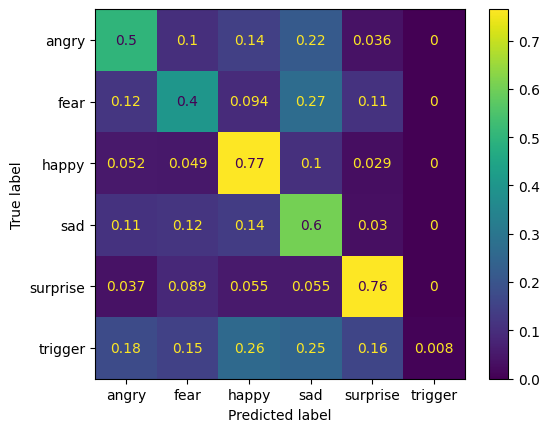

In [ ]:
# Evaluierung des Modells
print("Die Evaluierung ergibt folgendes Ergebnis:")
kerasmodel_alternativ.evaluate(X_test, y_test)

y_proba = kerasmodel_alternativ.predict(X_test)
y_pred = y_proba.argmax(axis=-1)

from sklearn.metrics import accuracy_score
keras_acc = accuracy_score(y_test, y_pred)
print("Die gemessene Genauigkeit beträgt: ", round(keras_acc,3))

listlabel = []
for i in labels_trigger.keys():
  listlabel.append(i)
listlabel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_keras = confusion_matrix(y_test, y_pred, labels=np.arange(len(listlabel)),normalize = 'true')
disp_keras = ConfusionMatrixDisplay(confusion_matrix=cm_keras, display_labels=listlabel)
disp_keras.plot()
plt.show()